In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Neurônio Sigmoid

In [35]:
def func_sigmoid(x, derivative=False):
    if derivative:
        y = func_sigmoid(x)
        return y * (1 - y)
    else:
        return 1 / (1 + np.exp(-x))

In [36]:
def Train_Sigmoid(X, Y, epochs, lr=0.1):
    n_amostras = len(X)
    n_atributos = len(X[0])

    W = [0.0] * n_atributos
    b = 0.0

    for _ in range(epochs):
        for i in range(n_amostras):

            z = 0.0
            
            for j in range(n_atributos):
                z += X[i][j] * W[j]
            z += b

            y_pred = func_sigmoid(z)
           
            erro = Y[i] - y_pred

            grad = erro * func_sigmoid(z, True)

            for j in range(n_atributos):
                W[j] += lr * grad * X[i][j]

            b += lr * grad

    return W, b

In [37]:
def predict_sigm(X, W, b):
    n_amostras = len(X)
    n_atributos = len(X[0])
    Y = [0.0] * n_amostras

    for i in range(n_amostras):
        z = 0.0

        # soma ponderada
        for j in range(n_atributos):
            z += X[i][j] * W[j]
        z += b

        Y[i] = func_sigmoid(z)

    return Y


# Testes

In [38]:
df = pd.read_csv('dados/anuncios.csv')

In [39]:
x, y = df.idade.values.reshape(-1,1), df.comprou.values.reshape(-1,1)

Text(0, 0.5, 'comprou?')

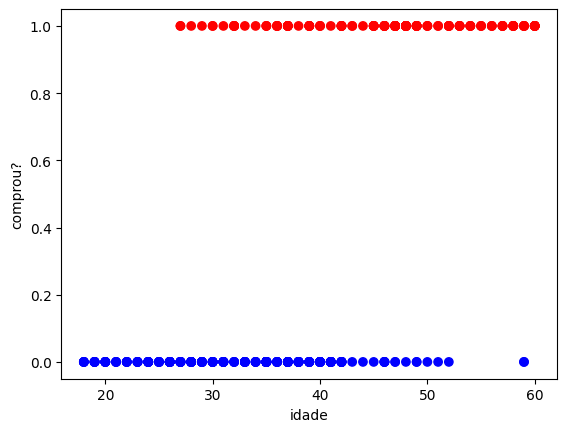

In [40]:
plt.scatter(x, y, c=y, cmap='bwr')
plt.xlabel('idade')
plt.ylabel('comprou?')

In [41]:
minmax = MinMaxScaler(feature_range=(-1,1))
x = minmax.fit_transform(x.astype(np.float64))

In [42]:
W, b = Train_Sigmoid(x, y, 150)

In [44]:
Y = predict_sigm(x, W, b)

Text(0, 0.5, 'comprou?')

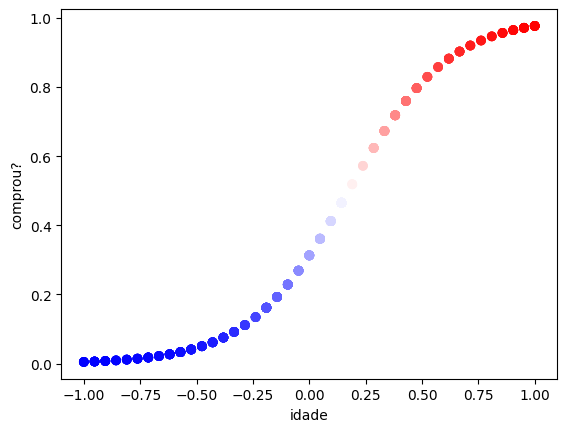

In [45]:
plt.scatter(x, Y, c=Y, cmap='bwr')
plt.xlabel('idade')
plt.ylabel('comprou?')